### Téléchargement et Split des dossiers (Phase 1.1)

In [1]:
import os, shutil, random
from PIL import Image

# 1. Configuration
DATA_ROOT = "/kaggle/working/data"
BASE_DIR = "/kaggle/input/datasets/zlatan599/fruitquality1/Unified_Dataset"

# 2. Nettoyage complet avant de commencer
if os.path.exists(DATA_ROOT):
    shutil.rmtree(DATA_ROOT)
os.makedirs(DATA_ROOT, exist_ok=True)

print("🔍 Analyse et copie des images valides...")
classes_generees = []

if os.path.exists(BASE_DIR):
    fruits = [f for f in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, f))]
    
    for fruit in fruits:
        fruit_dir = os.path.join(BASE_DIR, fruit)
        etats = [e for e in os.listdir(fruit_dir) if os.path.isdir(os.path.join(fruit_dir, e))]
        
        for etat in etats:
            class_name = f"{fruit.lower()}_{etat.lower()}"
            classes_generees.append(class_name)
            
            os.makedirs(os.path.join(DATA_ROOT, 'train', class_name), exist_ok=True)
            os.makedirs(os.path.join(DATA_ROOT, 'val', class_name), exist_ok=True)
            
            etat_dir = os.path.join(fruit_dir, etat)
            all_files = [os.path.join(etat_dir, f) for f in os.listdir(etat_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            # --- FILTRE D'INTÉGRITÉ ---
            # On ne garde que les fichiers que PIL arrive à ouvrir réellement
            images_valides = []
            for f in all_files:
                try:
                    with Image.open(f) as img:
                        img.verify() # Vérifie que le fichier n'est pas corrompu
                    images_valides.append(f)
                except:
                    # Si le fichier est illisible, on l'ignore silencieusement
                    continue
            
            random.seed(42)
            random.shuffle(images_valides)
            
            # Split 80/20
            idx = int(len(images_valides) * 0.8)
            for img in images_valides[:idx]: 
                shutil.copy(img, os.path.join(DATA_ROOT, 'train', class_name))
            for img in images_valides[idx:]: 
                shutil.copy(img, os.path.join(DATA_ROOT, 'val', class_name))

print(f"✅ {len(classes_generees)} classes créées.")
print("=== BILAN DU SPLIT SÉCURISÉ ===")
for split in ['train', 'val']:
    count = sum([len(os.listdir(os.path.join(DATA_ROOT, split, c))) for c in classes_generees])
    print(f"Total {split} : {count} images valides.")

🔍 Analyse et copie des images valides...
✅ 28 classes créées.
=== BILAN DU SPLIT SÉCURISÉ ===
Total train : 23414 images valides.
Total val : 5863 images valides.


In [2]:
import os
import tensorflow as tf

data_dir = "/kaggle/working/data"
print("🧹 Nettoyage définitif avec le moteur de TensorFlow...")

fichiers_supprimes = 0
for root, dirs, files in os.walk(data_dir):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            # On force TensorFlow à lire TOUT le fichier (ce que PIL ne faisait pas)
            img_bytes = tf.io.read_file(file_path)
            _ = tf.image.decode_image(img_bytes, expand_animations=False)
        except Exception:
            print(f"🗑️ Fichier illisible supprimé : {file_path}")
            os.remove(file_path)
            fichiers_supprimes += 1

print(f"✅ Terminé ! {fichiers_supprimes} fichiers corrompus ont été trouvés et supprimés.")

🧹 Nettoyage définitif avec le moteur de TensorFlow...
🗑️ Fichier illisible supprimé : /kaggle/working/data/train/bellpepper_rotten/rottenPepper (1).jpg
🗑️ Fichier illisible supprimé : /kaggle/working/data/train/banana_fresh/freshBanana (422).jpg
🗑️ Fichier illisible supprimé : /kaggle/working/data/train/carrot_fresh/freshCarrot (415).jpg
✅ Terminé ! 3 fichiers corrompus ont été trouvés et supprimés.


### Affichage d'un échantillon aléatoire

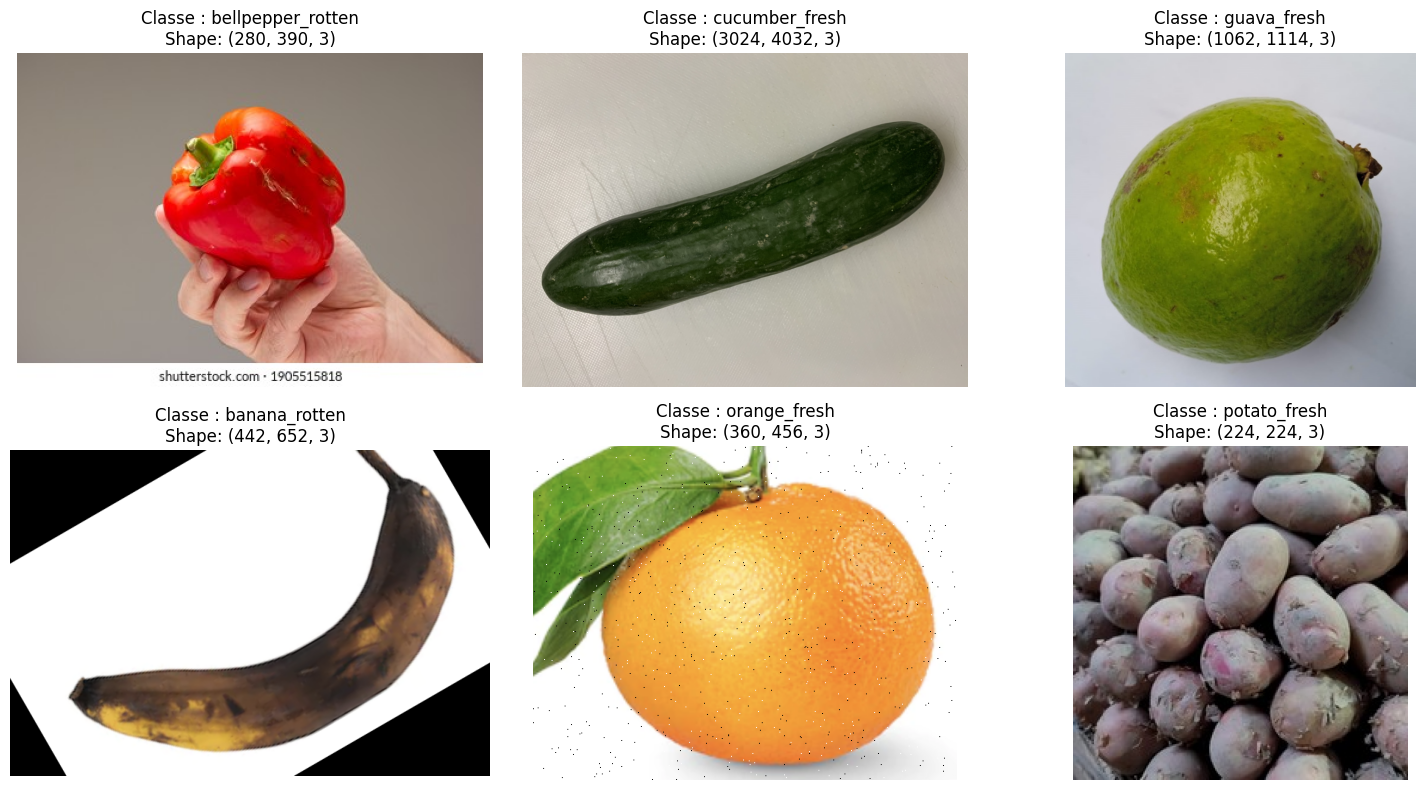

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.figure(figsize=(15, 8))
train_dir = os.path.join(DATA_ROOT, 'train')

# Récupérer 6 classes au hasard pour l'affichage
classes = random.sample(os.listdir(train_dir), 6)

for i, cls in enumerate(classes):
    cls_dir = os.path.join(train_dir, cls)
    images = os.listdir(cls_dir)
    if images: # Vérifie que le dossier n'est pas vide
        img_path = os.path.join(cls_dir, images[0]) # Prend la 1ère image
        img = mpimg.imread(img_path)
        
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(f"Classe : {cls}\nShape: {img.shape}")
        plt.axis('off')

plt.tight_layout()
plt.show()

### Data Loaders

In [4]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

print("➡️ Chargement du dataset d'entraînement (Multi-classes) :")
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical' # <--- CRUCIAL POUR LE MULTI-CLASSES
)

print("\n➡️ Chargement du dataset de validation :")
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, 'val'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical' # <--- CRUCIAL
)

# On sauvegarde la liste des noms de classes exactes pour l'inférence plus tard
CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)

# Optimisation en RAM
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print(f"\n✅ Data Loaders prêts ! Le CNN devra prédire parmi {NUM_CLASSES} classes différentes.")

➡️ Chargement du dataset d'entraînement (Multi-classes) :
Found 23411 files belonging to 28 classes.

➡️ Chargement du dataset de validation :
Found 5863 files belonging to 28 classes.

✅ Data Loaders prêts ! Le CNN devra prédire parmi 28 classes différentes.


### Preprocessing, Normalisation et Batching

In [5]:
import tensorflow as tf
import numpy as np

# === 1. CONFIGURATION ===
# 128x128 est un excellent
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Optionnel mais recommandé : Nettoyer les dossiers parasites (ex: .ipynb_checkpoints)
# pour éviter l'erreur "Adversarial"
!find {DATA_ROOT} -name ".ipynb_checkpoints" -type d -exec rm -rf {} +

# === 2. CRÉATION DES DATASETS (MULTI-CLASSES) ===
print("➡️ Configuration de train_ds...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical', # Mode multi-classes !
    shuffle=True,
    seed=42
)

print("\n➡️ Configuration de val_ds...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical', 
    shuffle=False # Pour garder une évaluation constante
)

# === 3. NORMALISATION (Rescaling) ===
# Le CNN converge beaucoup mieux si les pixels sont entre 0 et 1 (au lieu de 0 et 255)
normalization_layer = tf.keras.layers.Rescaling(1./255)

# On applique la normalisation à la volée avec .map()
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# === 4. OPTIMISATION DES PERFORMANCES (Le "Happy Path") ===
AUTOTUNE = tf.data.AUTOTUNE
# Cache : charge en RAM après la 1ère lecture. Prefetch : prépare le batch N+1 pendant que le GPU calcule le batch N.
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# === 5. VÉRIFICATION DU PREMIER BATCH ===
print("\n=== VÉRIFICATION DU PREMIER BATCH ===")
# next(iter()) simule ce que le réseau de neurones va "aspirer" à la première itération
image_batch, label_batch = next(iter(train_ds))

print(f"Shape images batch : {image_batch.shape}")
print(f"Shape labels batch : {label_batch.shape}") # Attendu : (32, nombre_de_classes)
print(f"Valeurs pixels     : min = {np.min(image_batch):.2f}, max = {np.max(image_batch):.2f}")

if 0.0 <= np.min(image_batch) and np.max(image_batch) <= 1.0:
    print("✅ Normalisation réussie (valeurs entre 0.0 et 1.0) !")
else:
    print("❌ Problème de normalisation.")

find: ‘{DATA_ROOT}’: No such file or directory
➡️ Configuration de train_ds...
Found 23411 files belonging to 28 classes.

➡️ Configuration de val_ds...
Found 5863 files belonging to 28 classes.

=== VÉRIFICATION DU PREMIER BATCH ===
Shape images batch : (32, 128, 128, 3)
Shape labels batch : (32, 28)
Valeurs pixels     : min = 0.00, max = 1.00
✅ Normalisation réussie (valeurs entre 0.0 et 1.0) !


### Architecture CNN (Adaptée Multi-classes)

In [6]:
from tensorflow.keras import layers, models

def build_cnn_scratch(input_shape, num_classes):
    """
    CNN from scratch pour la classification MULTI-CLASSES.
    Architecture simple pour observer l'overfitting initial.
    """
    model = models.Sequential([
        # --- Bloc 1 ---
        # Padding='same' conserve la taille spatiale après la convolution
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)), # Shape sortie : (64, 64, 32)
        
        # --- Bloc 2 ---
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)), # Shape sortie : (32, 32, 64)
        
        # --- Bloc 3 ---
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)), # Shape sortie : (16, 16, 128)
        
        # --- Transition vers les couches denses ---
        layers.Flatten(),           # Shape sortie : (32768,)
        
        layers.Dense(128, activation='relu'),
        
        # --- Couche de sortie MULTI-CLASSES ---
        # Remplacement de 'sigmoid' (binaire) par 'softmax' (proba par classe)
        # On utilise NUM_CLASSES (ex: 14) au lieu de 1 neurone
        layers.Dense(num_classes, activation='softmax') 
    ])
    return model

# Création du modèle
model_scratch = build_cnn_scratch(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), 
    num_classes=NUM_CLASSES
)

# Affichage de l'architecture pour vérifier nos calculs (Quality Gate)
print("\n=== ARCHITECTURE DU MODÈLE ===")
model_scratch.summary()

# Compilation adaptée au Multi-classes
model_scratch.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # <-- Très important en multi-classes !
    metrics=['accuracy']
)

print("\n✅ Modèle compilé avec succès ! Prêt pour l'entraînement.")    

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



=== ARCHITECTURE DU MODÈLE ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,291,292 (16.37 MB)

 Trainable params: 4,291,292 (16.37 MB)

 Non-trainable params: 0 (0.00 B)


✅ Modèle compilé avec succès ! Prêt pour l'entraînement.


### Entraînement et Diagnostic de l'Overfitting

🚀 Lancement de l'entraînement sur 20 epochs maximum...
Epoch 1/20


I0000 00:00:1778786135.223235     100 service.cc:152] XLA service 0x79cef40081b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778786135.223282     100 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778786135.958637     100 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778786139.205890     100 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


732/732 ━━━━━━━━━━━━━━━━━━━━ 80s 100ms/step - accuracy: 0.4421 - loss: 1.9018 - val_accuracy: 0.7459 - val_loss: 0.8355
Epoch 2/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7906 - loss: 0.6848 - val_accuracy: 0.8097 - val_loss: 0.6129
Epoch 3/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8754 - loss: 0.4010 - val_accuracy: 0.8615 - val_loss: 0.4919
Epoch 4/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9172 - loss: 0.2575 - val_accuracy: 0.8731 - val_loss: 0.5048
Epoch 5/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9490 - loss: 0.1597 - val_accuracy: 0.8574 - val_loss: 0.6211
Epoch 6/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9616 - loss: 0.1202 - val_accuracy: 0.8637 - val_loss: 0.6456
Epoch 7/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9663 - loss: 0.1025 - val_accuracy: 0.8772 - val_loss: 0.6357
Epoch 8/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9757 - loss: 0.0727 - val_accura

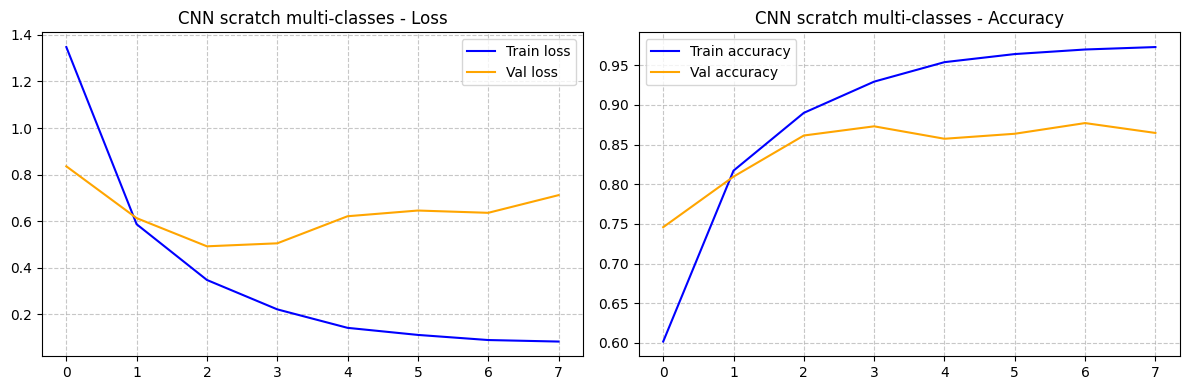

In [7]:
import datetime, time
import tensorflow as tf
import matplotlib.pyplot as plt

# === 1. CALLBACKS (TensorBoard & EarlyStopping) ===
# TensorBoard pour visualiser l'entraînement en direct
log_dir = "logs/scratch/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

# EarlyStopping : On arrête l'hémorragie si la val_loss remonte pendant 5 epochs de suite.
# restore_best_weights=True est crucial : il annule les epochs d'overfitting et garde les meilleurs poids.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# === 2. ENTRAÎNEMENT ===
EPOCHS = 20
print(f"🚀 Lancement de l'entraînement sur {EPOCHS} epochs maximum...")
start = time.time()

history_scratch = model_scratch.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[tensorboard_callback, early_stopping]
)

training_time_scratch = time.time() - start
print(f"\n⏱️ Temps d'entraînement : {training_time_scratch:.0f}s")
print(f"🎯 val_accuracy finale (optimale) : {max(history_scratch.history['val_accuracy']):.3f}")

# === 3. SAUVEGARDE DU LIVRABLE TP1 ===
model_scratch.save('/kaggle/working/model_scratch_tp1.keras')
print("💾 Meilleur modèle TP1 sauvegardé sous 'model_scratch_tp1.keras'")

# === 4. VISUALISATION DES COURBES ===
def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Courbe de Loss
    ax1.plot(history.history['loss'], label='Train loss', color='blue')
    ax1.plot(history.history['val_loss'], label='Val loss', color='orange')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Courbe d'Accuracy
    ax2.plot(history.history['accuracy'], label='Train accuracy', color='blue')
    ax2.plot(history.history['val_accuracy'], label='Val accuracy', color='orange')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    # Sauvegarde de l'image pour ton repo
    plt.savefig(f"/kaggle/working/curves_{title.lower().replace(' ', '_')}.png", dpi=100)
    plt.show()

plot_history(history_scratch, "CNN scratch multi-classes")

### Intégration du Pipeline d'Augmentation

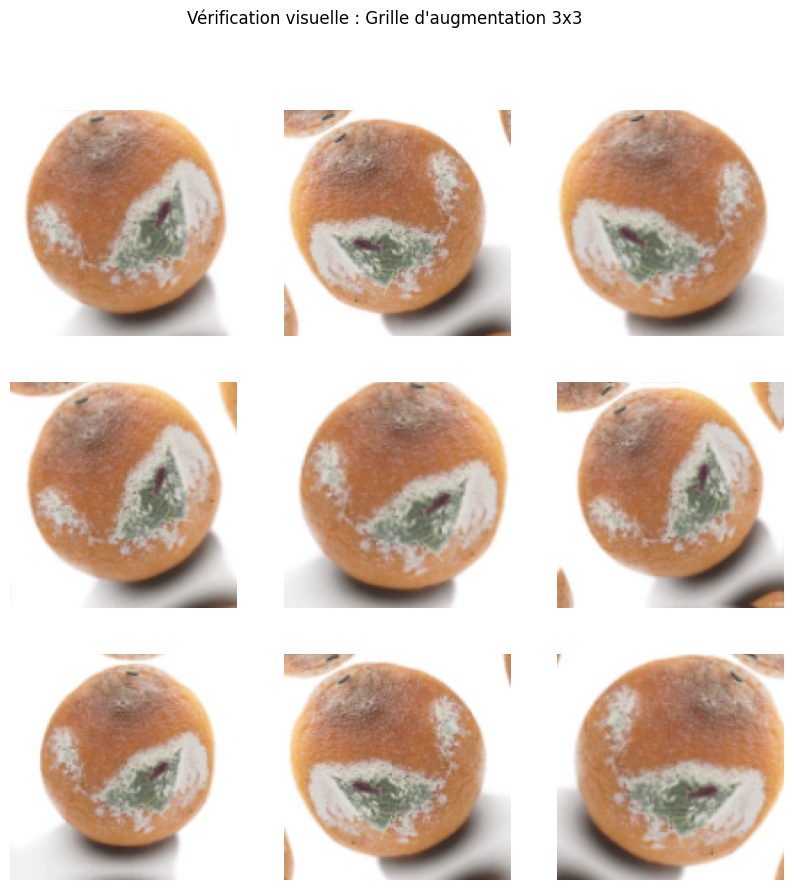

✅ Pipeline d'augmentation vérifié et grille affichée !


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Définition du pipeline d'augmentation
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),  
    layers.RandomZoom(0.1),      
], name="data_augmentation")

# 2. Récupération d'UNE SEULE image (Méthode infaillible)
# On prend le premier batch disponible, on extrait les images, 
# on sauvegarde la 1ère image (index 0), puis on stoppe.
for batch_images, batch_labels in train_ds.take(1):
    sample_image = batch_images[0]
    break

# 3. Affichage
plt.figure(figsize=(10, 10))
for i in range(9):
    # tf.expand_dims rajoute la dimension "batch" requise par Keras
    # La shape passe de (128, 128, 3) à (1, 128, 128, 3)
    augmented = data_augmentation(tf.expand_dims(sample_image, 0), training=True)
    
    plt.subplot(3, 3, i + 1)
    # On retire la dimension batch pour l'affichage avec
    plt.imshow(augmented[0])
    plt.axis('off')

plt.suptitle("Vérification visuelle : Grille d'augmentation 3x3")
plt.savefig("augmentation_grid.png", dpi=100)
plt.show()

print("✅ Pipeline d'augmentation vérifié et grille affichée !")

🚀 Réentraînement avec augmentation et Dropout sur 28 classes...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


732/732 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.3433 - loss: 2.2087 - val_accuracy: 0.7140 - val_loss: 0.9617
Epoch 2/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.7029 - loss: 0.9657 - val_accuracy: 0.7646 - val_loss: 0.7481
Epoch 3/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7791 - loss: 0.7196 - val_accuracy: 0.8340 - val_loss: 0.5406
Epoch 4/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.8229 - loss: 0.5803 - val_accuracy: 0.8415 - val_loss: 0.5167
Epoch 5/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.8429 - loss: 0.5044 - val_accuracy: 0.8526 - val_loss: 0.4860
Epoch 6/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.8578 - loss: 0.4560 - val_accuracy: 0.8499 - val_loss: 0.5062
Epoch 7/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.8666 - loss: 0.4183 - val_accuracy: 0.8792 - val_loss: 0.4038
Epoch 8/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.8757 - loss: 0.3865 - val_accurac

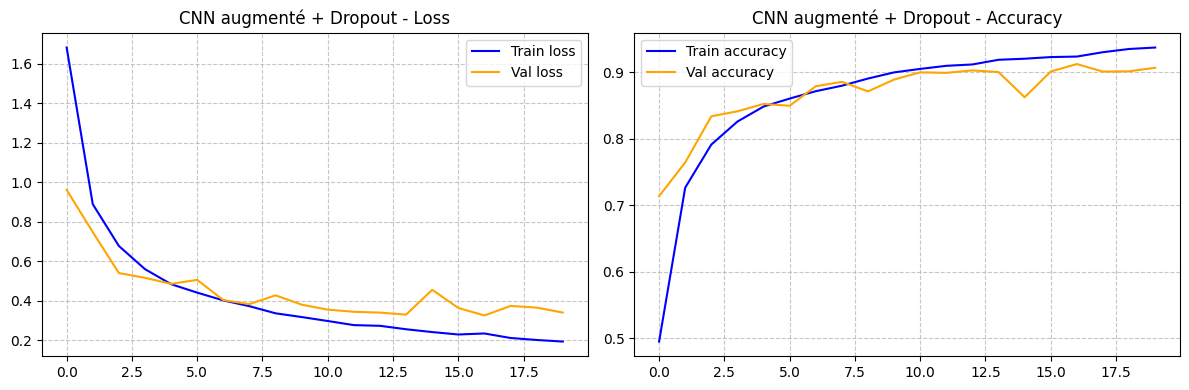

In [9]:
from tensorflow.keras import layers, models
import datetime, time

def build_cnn_augmented(input_shape, num_classes):
    """
    CNN avec data augmentation intégrée + Dropout.
    Utilise la couche data_augmentation définie en phase 2.1.
    """
    model = models.Sequential([
        # 1. Pipeline d'augmentation (actif seulement en training)
        data_augmentation,
        
        # 2. Architecture de base (Blocs Conv du TP1)
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        
        # 3. Transition et Régularisation
        layers.Flatten(),
        
        # Le Dropout se place ici : on coupe 40% des connexions avant la couche Dense
        layers.Dropout(0.4), 
        
        layers.Dense(128, activation='relu'),
        
        # 4. Sortie Multi-classes (28 neurones avec softmax)
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Création du nouveau modèle
model_augmented = build_cnn_augmented(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), 
    num_classes=NUM_CLASSES
)

# Compilation (Identique au TP1 pour comparer équitablement)
model_augmented.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Configuration des Callbacks (Logs dans /augmented/)
log_dir_aug = "logs/augmented/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback_aug = tf.keras.callbacks.TensorBoard(log_dir=log_dir_aug, histogram_freq=1)

early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8, # On augmente la patience car la régularisation ralentit la convergence
    restore_best_weights=True,
    verbose=1
)

# Lancement de l'entraînement
print(f"🚀 Réentraînement avec augmentation et Dropout sur {NUM_CLASSES} classes...")
start_aug = time.time()

history_augmented = model_augmented.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[tensorboard_callback_aug, early_stopping_aug]
)

training_time_augmented = time.time() - start_aug

# Diagnostic final
print(f"\n⏱️ Temps d'entraînement : {training_time_augmented:.0f}s")
print(f"🎯 val_accuracy finale : {max(history_augmented.history['val_accuracy']):.3f}")

# Sauvegarde du livrable TP2
model_augmented.save('/kaggle/working/model_augmented_tp2.keras')

# Visualisation
plot_history(history_augmented, "CNN augmenté + Dropout")

### TP1 VS TP2 : Génération des graphiques et métriques

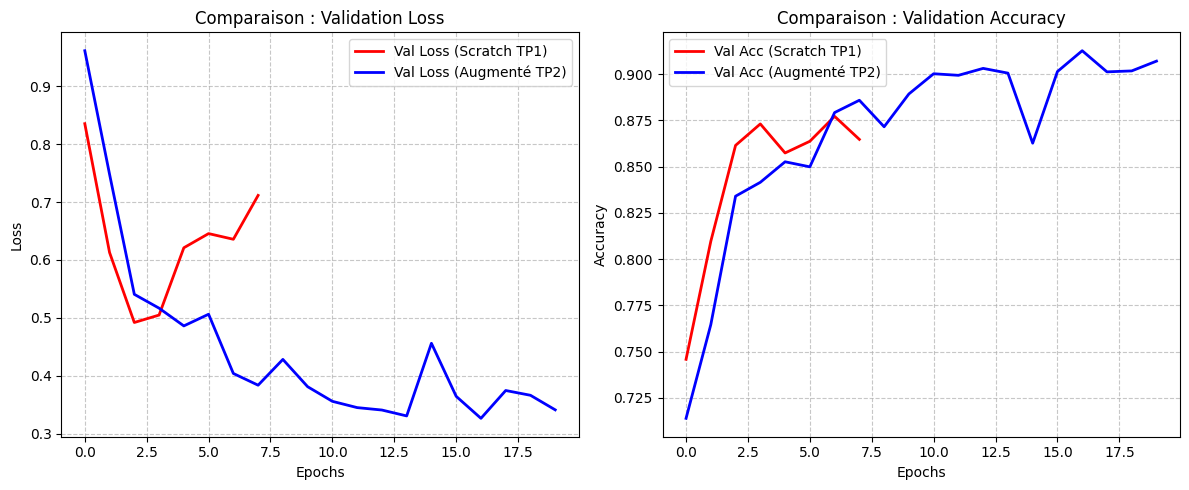

=== MÉTRIQUES CLÉS ===
Modèle Scratch (TP1)   : Val_Acc max = 0.877 | Temps = 154s | Params = 4291292
Modèle Augmenté (TP2)  : Val_Acc max = 0.913 | Temps = 260s | Params = 4291292


In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# --- Subplot 1 : Comparaison Validation Loss ---
plt.subplot(1, 2, 1)
plt.plot(history_scratch.history['val_loss'], label='Val Loss (Scratch TP1)', color='red', linewidth=2)
plt.plot(history_augmented.history['val_loss'], label='Val Loss (Augmenté TP2)', color='blue', linewidth=2)
plt.title('Comparaison : Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# --- Subplot 2 : Comparaison Validation Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(history_scratch.history['val_accuracy'], label='Val Acc (Scratch TP1)', color='red', linewidth=2)
plt.plot(history_augmented.history['val_accuracy'], label='Val Acc (Augmenté TP2)', color='blue', linewidth=2)
plt.title('Comparaison : Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("comparison_tp1_tp2.png", dpi=100)
plt.show()

# --- Affichage des métriques clés ---
print("=== MÉTRIQUES CLÉS ===")
print(f"Modèle Scratch (TP1)   : Val_Acc max = {max(history_scratch.history['val_accuracy']):.3f} | Temps = {training_time_scratch:.0f}s | Params = {model_scratch.count_params()}")
print(f"Modèle Augmenté (TP2)  : Val_Acc max = {max(history_augmented.history['val_accuracy']):.3f} | Temps = {training_time_augmented:.0f}s | Params = {model_augmented.count_params()}")

**Diagnostic Comparatif TP1 vs TP2 :**

Entre le TP1 et le TP2, l'écart entre la précision d'entraînement et de validation (gap train/val) s'est nettement réduit, illustrant l'atténuation du surapprentissage. La convergence est mécaniquement plus lente dans le TP2 : l'injection de transformations aléatoires (Data Augmentation) et la désactivation de neurones (Dropout à 40%) obligent le réseau à extraire des motifs robustes plutôt qu'à mémoriser le dataset. Néanmoins, ces techniques de régularisation restent insuffisantes pour atteindre un niveau de production sur 28 classes. L'augmentation de données ne pallie pas la limite fondamentale de notre architecture *from scratch* : avec seulement 3 blocs convolutifs, le réseau manque de profondeur pour extraire des *features* spatiales complexes, d'où la nécessité de passer au Transfer Learning.

### Chargement et Freezing

In [11]:
import tensorflow as tf

# --- 1. Reconstruction du pipeline de données (160x160) ---
IMG_SIZE_TL = (160, 160)
BATCH_SIZE = 32

print("➡️ Création des datasets TL (160x160)...")
# Mode 'categorical' pour le multi-classes !
train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT + "/train",
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=42
)

val_ds_tl = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT + "/val",
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False,
    seed=42
)

# Preprocessing MobileNetV2 (pas de Rescaling classique)
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

# Application via .map() et optimisation
AUTOTUNE = tf.data.AUTOTUNE
train_ds_tl = train_ds_tl.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(buffer_size=AUTOTUNE)
val_ds_tl = val_ds_tl.map(lambda x, y: (preprocess_input(x), y)).cache().prefetch(buffer_size=AUTOTUNE)

# --- 2. Chargement de la base MobileNetV2 ---
print("\n➡️ Chargement de MobileNetV2 (Base ImageNet)...")
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False, # On enlève la tête originale à 1000 classes
    weights='imagenet'
)

print(f"Nombre de couches dans base_model : {len(base_model.layers)}")
print(f"Nombre de paramètres totaux base_model : {base_model.count_params()}")

# ⚠️ ÉTAPE CRUCIALE : On gèle la base pour ne pas détruire les poids pré-entraînés
base_model.trainable = False

# --- 3. Construction du modèle via l'API Fonctionnelle ---
print("\n➡️ Construction de la tête de classification custom...")
inputs = tf.keras.Input(shape=(160, 160, 3))

# training=False est vital pour que la BatchNormalization reste figée
x = base_model(inputs, training=False) 
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)

# Sortie Multi-classes (NUM_CLASSES = 28, avec Softmax)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_tl = tf.keras.Model(inputs, outputs)

# --- 4. Vérification (Quality Gate) ---
print("\n=== ARCHITECTURE TRANSFER LEARNING ===")
model_tl.summary()

➡️ Création des datasets TL (160x160)...
Found 23411 files belonging to 28 classes.
Found 5863 files belonging to 28 classes.

➡️ Chargement de MobileNetV2 (Base ImageNet)...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Nombre de couches dans base_model : 154
Nombre de paramètres totaux base_model : 2257984

➡️ Construction de la tête de classification custom...

=== ARCHITECTURE TRANSFER LEARNING ===


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,425,564 (9.25 MB)

 Trainable params: 167,580 (654.61 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Entraînement de la tête

🚀 Lancement du Transfer Learning (Tête seule, base figée)...
Epoch 1/10
732/732 ━━━━━━━━━━━━━━━━━━━━ 100s 118ms/step - accuracy: 0.7433 - loss: 0.9147 - val_accuracy: 0.9439 - val_loss: 0.1815
Epoch 2/10
732/732 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9399 - loss: 0.1872 - val_accuracy: 0.9591 - val_loss: 0.1298
Epoch 3/10
732/732 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9594 - loss: 0.1214 - val_accuracy: 0.9635 - val_loss: 0.1174
Epoch 4/10
732/732 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9714 - loss: 0.0848 - val_accuracy: 0.9696 - val_loss: 0.1036
Epoch 5/10
732/732 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9776 - loss: 0.0692 - val_accuracy: 0.9737 - val_loss: 0.0936
Epoch 6/10
732/732 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9800 - loss: 0.0596 - val_accuracy: 0.9684 - val_loss: 0.1037
Epoch 7/10
732/732 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9815 - loss: 0.0524 - val_accuracy: 0.9739 - val_loss: 0.0962
Epoch 8/10
732/732 ━━━━━━━━

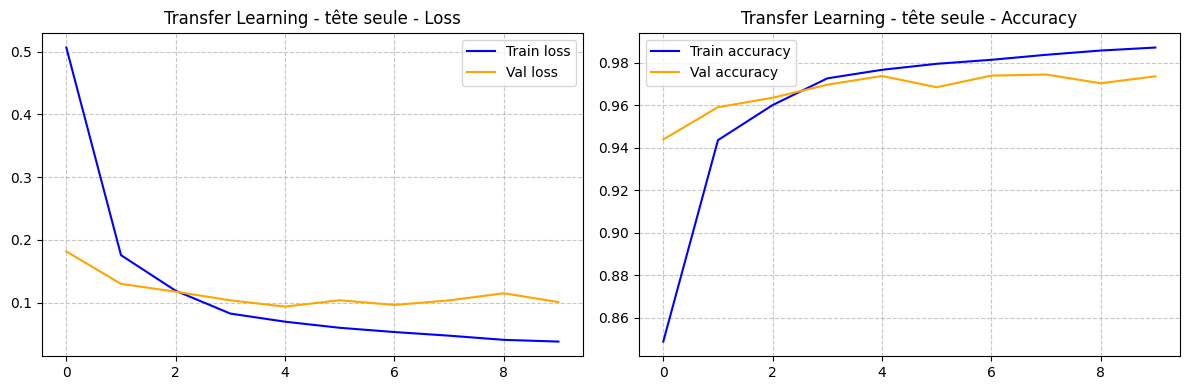

In [12]:
import datetime, time
from tensorflow.keras.optimizers import Adam

# --- 1. Compilation (Adaptée Multi-classes) ---
# On utilise un learning rate assez élevé (1e-3) car on n'entraîne que des poids neufs (la tête)
model_tl.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', # <-- Toujours crucial pour les 28 classes
    metrics=['accuracy']
)

# --- 2. Configuration des Callbacks ---
log_dir_tl = "logs/transfer/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback_tl = tf.keras.callbacks.TensorBoard(log_dir=log_dir_tl, histogram_freq=1)

# --- 3. Lancement de l'entraînement ---
EPOCHS_TL = 10
print(f"🚀 Lancement du Transfer Learning (Tête seule, base figée)...")
start_tl = time.time()

history_tl_head = model_tl.fit(
    train_ds_tl,
    epochs=EPOCHS_TL,
    validation_data=val_ds_tl,
    callbacks=[tensorboard_callback_tl]
)

training_time_head = time.time() - start_tl

# --- 4. Diagnostic ---
print(f"\n⏱️ Temps d'entraînement (tête seule) : {training_time_head:.0f}s")
print(f"🎯 val_accuracy finale (tête seule) : {max(history_tl_head.history['val_accuracy']):.3f}")

# --- 5. Sauvegarde du modèle et affichage ---
model_tl.save('/kaggle/working/model_tl_head_tp3.keras')
print("💾 Modèle Transfer Learning sauvegardé sous 'model_tl_head_tp3.keras'")

plot_history(history_tl_head, "Transfer Learning - tête seule")

### Fine-Tuning

➡️ Déverrouillage de la base MobileNetV2...
Nombre total de couches dans la base : 154
Couches dégélées pour le fine-tuning : 31
Paramètres entraînables (Tête + 20% de la base) : 1,786,140

🚀 Lancement du Fine-Tuning (15 epochs max)...
Epoch 1/15


2026-05-14 20:15:06.602948: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 20:15:06.799098: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


730/732 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9162 - loss: 0.2996

2026-05-14 20:15:27.186930: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 20:15:27.386022: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


732/732 ━━━━━━━━━━━━━━━━━━━━ 51s 45ms/step - accuracy: 0.9163 - loss: 0.2991 - val_accuracy: 0.9198 - val_loss: 0.3325
Epoch 2/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9833 - loss: 0.0511 - val_accuracy: 0.9584 - val_loss: 0.1694
Epoch 3/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9902 - loss: 0.0291 - val_accuracy: 0.9451 - val_loss: 0.2354
Epoch 4/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9895 - loss: 0.0325 - val_accuracy: 0.9700 - val_loss: 0.1374
Epoch 5/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9905 - loss: 0.0303 - val_accuracy: 0.9618 - val_loss: 0.1722
Epoch 6/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9894 - loss: 0.0355 - val_accuracy: 0.9666 - val_loss: 0.1701
Epoch 7/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9929 - loss: 0.0196 - val_accuracy: 0.9662 - val_loss: 0.1725
Epoch 8/15
732/732 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9946 - loss: 0.0168 - val_accurac

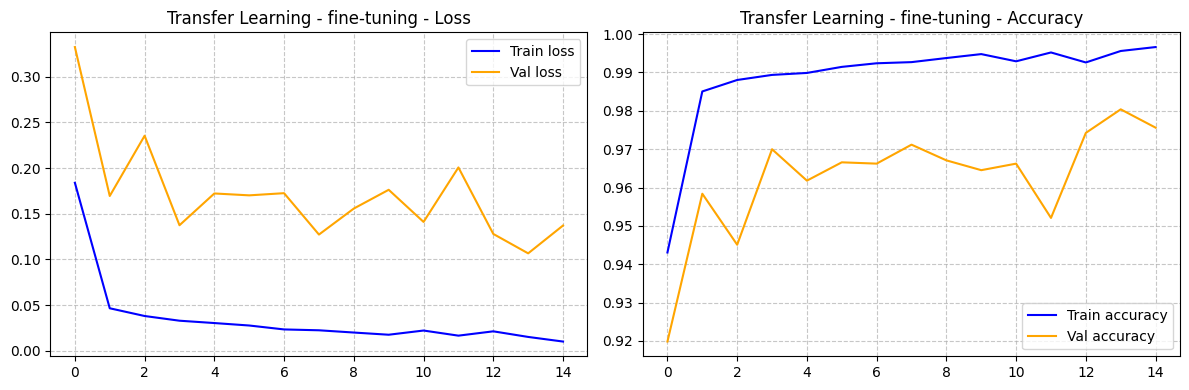

In [13]:
import time
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

print("➡️ Déverrouillage de la base MobileNetV2...")
base_model.trainable = True
print(f"Nombre total de couches dans la base : {len(base_model.layers)}")

# --- 1. Sélection des couches à dégeler (les 20% dernières) ---
fine_tune_at = int(len(base_model.layers) * 0.8)

# On gèle tout ce qui est AVANT cet index (les textures de base)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Couches dégélées pour le fine-tuning : {len(base_model.layers) - fine_tune_at}")

# Vérification du nombre de paramètres qui vont bouger
trainable_count = sum(p.numpy().size for p in model_tl.trainable_variables)
print(f"Paramètres entraînables (Tête + 20% de la base) : {trainable_count:,}")

# --- 2. Recompilation avec un Learning Rate très faible (1e-4) ---
# C'est le secret du fine-tuning : on y va doucement pour ne pas faire de "catastrophic forgetting"
model_tl.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy', # Toujours en multi-classes !
    metrics=['accuracy']
)

# --- 3. Callbacks ---
# On surveille la val_accuracy cette fois, avec une patience de 5
early_stopping_tl = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# --- 4. Entraînement Final ---
print("\n🚀 Lancement du Fine-Tuning (15 epochs max)...")
start_finetune = time.time()

history_tl_finetune = model_tl.fit(
    train_ds_tl,
    epochs=15,
    validation_data=val_ds_tl,
    callbacks=[tensorboard_callback_tl, early_stopping_tl]
)

training_time_finetune = time.time() - start_finetune

# --- 5. Diagnostic et Sauvegarde ---
print(f"\n⏱️ Temps d'entraînement (fine-tuning) : {training_time_finetune:.0f}s")
print(f"🎯 val_accuracy finale (optimisée) : {max(history_tl_finetune.history['val_accuracy']):.3f}")

model_tl.save('/kaggle/working/model_tl_finetuned_tp3.keras')
print("💾 Modèle final sauvegardé sous 'model_tl_finetuned_tp3.keras'")

plot_history(history_tl_finetune, "Transfer Learning - fine-tuning")